这个文件主要是处理OⅠ线

In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

In [25]:
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[785,:,:]+201)#对应时间21：04：35

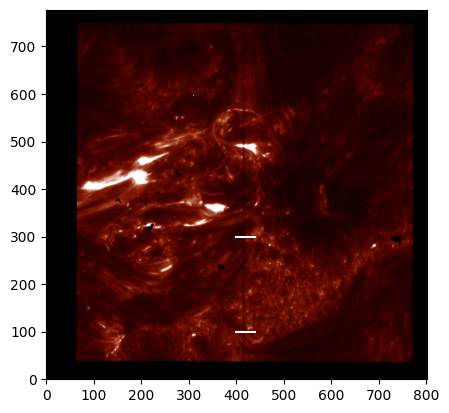

In [26]:
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
plt.plot([400, 440], [100, 100], linestyle='-', color='white')
plt.plot([400, 440], [300, 300], linestyle='-', color='white')
# plt.plot([400, 440], [550, 550], linestyle='-', color='white')
# plt.plot([400, 440], [700, 700], linestyle='-', color='white')


In [31]:
print(file_list[392])

C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\iris_l2_20240618_163141_3602506433_raster_t000_r00392.fits


In [27]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[392])#对应时间21：04：35
spectrum=rsm[2].data[4,:,:]
exptime=rsm[0].header['EXPTIME']
from array_despike import array_despike
#IRIS会将一些NaN设置为-200
valid_mask = (
    np.isfinite(spectrum)
    & (spectrum != -200)
)

spectrum_clean, info = array_despike(
    spectrum,
    sigma=8.0,
    threshold=6.0,
    itmax=20,
    no_low=False,
    valid_mask=valid_mask,
    return_info=True,
    verbose=True,
)

print(info["n_changed_unique"])

bright pass 0: replaced 679 pixels
bright pass 1: replaced 88 pixels
bright pass 2: replaced 23 pixels
bright pass 3: replaced 13 pixels
bright pass 4: replaced 2 pixels
bright pass 5: replaced 1 pixels
bright pass 6: replaced 0 pixels
dark pass 0: replaced 2 pixels
dark pass 1: replaced 0 pixels
787


有多少个NaN值 1267
拟合得到的OI多普勒速度为 14.341132335123286 km/s
拟合得到的CI多普勒速度为 12.957000206346345 km/s


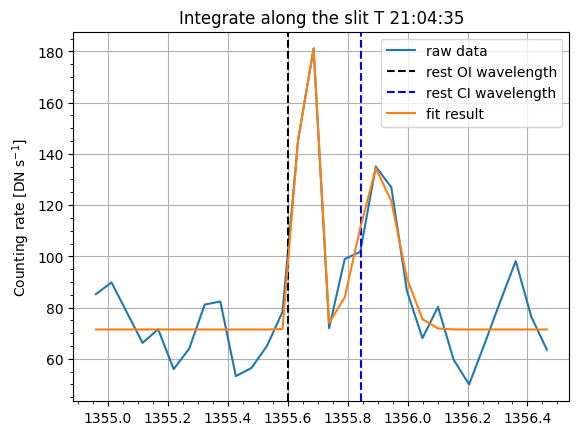

In [28]:
wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)
# selected = np.concatenate(
#     [spectrum_clean[100:300, :],
#      spectrum_clean[550:700, :]],
#     axis=0
# )
selected = spectrum_clean[100:300, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -200))
selected[selected == -200] = np.nan
wave_y1 = np.nansum(selected, axis=0)
wave_y1=wave_y1/exptime
#wave_y1=(np.vstack((spectrum_clean[100:300,:],spectrum_clean[550:700,:]))).sum(axis=0)
start_point,end_point=155,185
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Counting rate [DN s$^{-1}$]")
plt.title('Integrate along the slit T 21:04:35')
plt.legend()
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
plt.legend()
plt.minorticks_on()
plt.grid()

In [17]:
print(wave_x[start_point:end_point][0],wave_x[start_point:end_point][-1],wave_x[start_point:end_point].shape)

1354.9594999999895 1356.4645999999875 (30,)


In [ ]:
#----------------------------------------------------------------------------------------------------------------
#换几个时间再看看会不会有这么明显的速度
#----------------------------------------------------------------------------------------------------------------

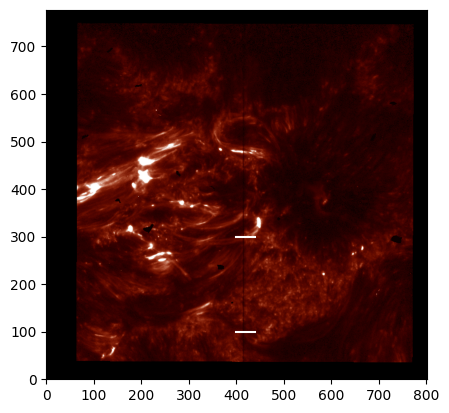

In [21]:


rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[625,:,:]+201)#对应时间20:08:58

plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
plt.plot([400, 440], [100, 100], linestyle='-', color='white')
plt.plot([400, 440], [300, 300], linestyle='-', color='white')

bright pass 0: replaced 656 pixels
bright pass 1: replaced 91 pixels
bright pass 2: replaced 30 pixels
bright pass 3: replaced 20 pixels
bright pass 4: replaced 5 pixels
bright pass 5: replaced 1 pixels
bright pass 6: replaced 0 pixels
dark pass 0: replaced 5 pixels
dark pass 1: replaced 0 pixels
757
有多少个NaN值 1293
拟合得到的OI多普勒速度为 13.14589804847208 km/s
拟合得到的CI多普勒速度为 14.77148029528333 km/s


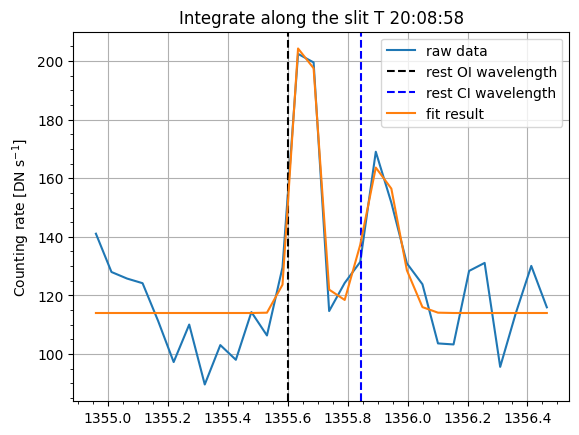

In [24]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[312])#对应时间20:08:58
spectrum=rsm[2].data[4,:,:]
exptime=rsm[0].header['EXPTIME']
from array_despike import array_despike
#IRIS会将一些NaN设置为-200
valid_mask = (
    np.isfinite(spectrum)
    & (spectrum != -200)
)

spectrum_clean, info = array_despike(
    spectrum,
    sigma=8.0,
    threshold=6.0,
    itmax=20,
    no_low=False,
    valid_mask=valid_mask,
    return_info=True,
    verbose=True,
)

print(info["n_changed_unique"])

wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)
# selected = np.concatenate(
#     [spectrum_clean[100:300, :],
#      spectrum_clean[550:700, :]],
#     axis=0
# )
selected = spectrum_clean[100:300, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -200))
selected[selected == -200] = np.nan
wave_y1 = np.nansum(selected, axis=0)
wave_y1=wave_y1/exptime
#wave_y1=(np.vstack((spectrum_clean[100:300,:],spectrum_clean[550:700,:]))).sum(axis=0)
start_point,end_point=155,185
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Counting rate [DN s$^{-1}$]")
plt.title('Integrate along the slit T 20:08:58')
plt.legend()
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
plt.legend()
plt.minorticks_on()
plt.grid()

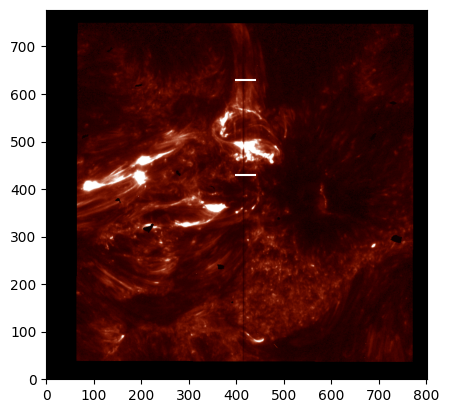

In [68]:
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[775,:,:]+201)#对应时间16:43:10

plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
plt.plot([400, 440], [430, 430], linestyle='-', color='white')
plt.plot([400, 440], [630, 630], linestyle='-', color='white')

bright pass 0: replaced 574 pixels
bright pass 1: replaced 95 pixels
bright pass 2: replaced 35 pixels
bright pass 3: replaced 19 pixels
bright pass 4: replaced 4 pixels
bright pass 5: replaced 0 pixels
dark pass 0: replaced 10 pixels
dark pass 1: replaced 2 pixels
dark pass 2: replaced 0 pixels
683
有多少个NaN值 1293
拟合得到的OI多普勒速度为 13.117394403880976 km/s
拟合得到的CI多普勒速度为 16.973258650388257 km/s


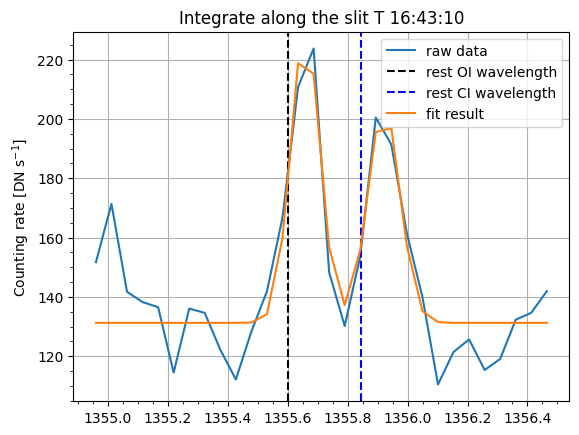

In [30]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[16])#对应时间20:08:58
spectrum=rsm[2].data[4,:,:]
exptime=rsm[0].header['EXPTIME']
from array_despike import array_despike
#IRIS会将一些NaN设置为-200
valid_mask = (
    np.isfinite(spectrum)
    & (spectrum != -200)
)

spectrum_clean, info = array_despike(
    spectrum,
    sigma=8.0,
    threshold=6.0,
    itmax=20,
    no_low=False,
    valid_mask=valid_mask,
    return_info=True,
    verbose=True,
)

print(info["n_changed_unique"])

wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)

selected = spectrum_clean[100:300, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -200))
selected[selected == -200] = np.nan
wave_y1 = np.nansum(selected, axis=0)
wave_y1=wave_y1/exptime
#wave_y1=(np.vstack((spectrum_clean[100:300,:],spectrum_clean[550:700,:]))).sum(axis=0)
start_point,end_point=155,185
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Counting rate [DN s$^{-1}$]")
plt.title('Integrate along the slit T 16:43:10')
plt.legend()
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
plt.legend()
plt.minorticks_on()
plt.grid()

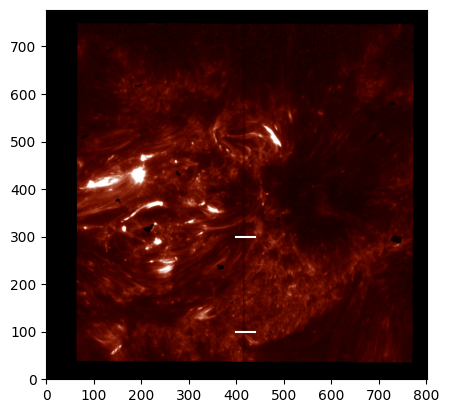

In [32]:
new_map=np.log(sji1400[967,:,:]+201)#对应时间22：07：51

plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
plt.plot([400, 440], [100, 100], linestyle='-', color='white')
plt.plot([400, 440], [300, 300], linestyle='-', color='white')

bright pass 0: replaced 741 pixels
bright pass 1: replaced 96 pixels
bright pass 2: replaced 15 pixels
bright pass 3: replaced 8 pixels
bright pass 4: replaced 1 pixels
bright pass 5: replaced 0 pixels
dark pass 0: replaced 0 pixels
841
有多少个NaN值 1277
拟合得到的OI多普勒速度为 12.263094491601809 km/s
拟合得到的CI多普勒速度为 12.462743160439768 km/s


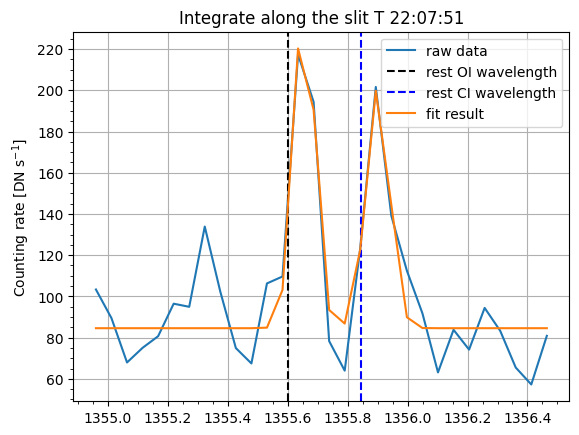

In [33]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[483])#对应时间22:07:51
spectrum=rsm[2].data[4,:,:]
exptime=rsm[0].header['EXPTIME']
from array_despike import array_despike
#IRIS会将一些NaN设置为-200
valid_mask = (
    np.isfinite(spectrum)
    & (spectrum != -200)
)

spectrum_clean, info = array_despike(
    spectrum,
    sigma=8.0,
    threshold=6.0,
    itmax=20,
    no_low=False,
    valid_mask=valid_mask,
    return_info=True,
    verbose=True,
)

print(info["n_changed_unique"])

wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)

selected = spectrum_clean[100:300, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -200))
selected[selected == -200] = np.nan
wave_y1 = np.nansum(selected, axis=0)
wave_y1=wave_y1/exptime
#wave_y1=(np.vstack((spectrum_clean[100:300,:],spectrum_clean[550:700,:]))).sum(axis=0)
start_point,end_point=155,185
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Counting rate [DN s$^{-1}$]")
plt.title('Integrate along the slit T 22:07:51')
plt.legend()
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
plt.legend()
plt.minorticks_on()
plt.grid()

In [ ]:
#一：画一下下面这段宁静区得到的速度随时间的变化（感觉变化不会很大）
#二：将下面这片区域空间上小的间隔开，看速度的变化
#三：选取目标区域爆发前一个比较宁静的时间段

In [87]:
#一：从Frame621(20:07:34)开始，时间上三张图在一块增加信噪比（cadence 21s)
from array_despike import array_despike
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
spectrum_clean_all=[]

for i in range(310,397):
    rsm=fits.open(file_list[i])
    spectrum=rsm[2].data[4,:,:]
    exptime=rsm[0].header['EXPTIME']

    #IRIS会将一些NaN设置为-200
    valid_mask = (
        np.isfinite(spectrum)
        & (spectrum != -200)
    )

    spectrum_clean, info = array_despike(
        spectrum,
        sigma=8.0,
        threshold=6.0,
        itmax=20,
        no_low=False,
        valid_mask=valid_mask,
        return_info=True,
        verbose=True,
    )
    spectrum_clean_all.append(spectrum_clean)

bright pass 0: replaced 703 pixels
bright pass 1: replaced 91 pixels
bright pass 2: replaced 27 pixels
bright pass 3: replaced 5 pixels
bright pass 4: replaced 2 pixels
bright pass 5: replaced 4 pixels
bright pass 6: replaced 2 pixels
bright pass 7: replaced 3 pixels
bright pass 8: replaced 2 pixels
bright pass 9: replaced 1 pixels
bright pass 10: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 621 pixels
bright pass 1: replaced 87 pixels
bright pass 2: replaced 23 pixels
bright pass 3: replaced 12 pixels
bright pass 4: replaced 10 pixels
bright pass 5: replaced 7 pixels
bright pass 6: replaced 2 pixels
bright pass 7: replaced 0 pixels
dark pass 0: replaced 1 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 656 pixels
bright pass 1: replaced 91 pixels
bright pass 2: replaced 30 pixels
bright pass 3: replaced 20 pixels
bright pass 4: replaced 5 pixels
bright pass 5: replaced 1 pixels
bright pass 6: replaced 0 pixels
dark pass 0: replaced 5 pixels
da

In [89]:
wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)
doppler_all=np.zeros((29,2))
#接下来进行空间上积分和时间上的三合一
time_axis = pd.date_range(
    start="20:07:34",
    periods=29,
    freq="126s"
)
for i in range(29):
    selected = spectrum_clean_all[i*3][100:300,:]+spectrum_clean_all[i*3+1][100:300,:]+spectrum_clean_all[i*3+2][100:300, :]
    selected = selected.astype(float)
    print('有多少个NaN值',np.count_nonzero(selected == -600))
    selected[selected == -600] = np.nan
    wave_y1 = np.nansum(selected, axis=0)
    wave_y1=wave_y1/(exptime*3)
    start_point,end_point=155,185
    try:
        plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
        plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
        plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
        plt.ylabel(r"Counting rate [DN s$^{-1}$]")
        plt.title(str(i))
        plt.legend()
        from gaussian_fit import fit_double_gaussian
        result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
        centers = np.array([result['center1'], result['center2']])
        centers = np.sort(centers)

        center_OI = centers[0]
        center_CI = centers[1]

        doppler_all[i, 0] = (center_OI - 1355.599) / 1355.599 * 2.997e5
        doppler_all[i, 1] = (center_CI - 1355.844) / 1355.844 * 2.997e5
        plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
        plt.title(time_axis[i])
        plt.minorticks_on()
        plt.grid()
        plt.text(
            0.03, 0.95,
            f"OI Doppler = {doppler_all[i,0]:.2f} km/s\nCI Doppler = {doppler_all[i,1]:.2f} km/s",
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )
        plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\OI_fig_quiet\{i}.png'.format(i=i))

    except:
        doppler_all[i,0]=np.nan
        doppler_all[i,1]=np.nan
        print(f"Failed to fit double Gaussian for index {i}")
    plt.close()

有多少个NaN值 1289
有多少个NaN值 1291
Failed to fit double Gaussian for index 1
有多少个NaN值 1288
有多少个NaN值 1290
有多少个NaN值 1286
有多少个NaN值 1286
有多少个NaN值 1276
有多少个NaN值 1280
有多少个NaN值 1278
有多少个NaN值 1272
有多少个NaN值 1275
有多少个NaN值 1272
有多少个NaN值 1273
有多少个NaN值 1270
有多少个NaN值 1265
有多少个NaN值 1266
有多少个NaN值 1267
有多少个NaN值 1266
有多少个NaN值 1267
有多少个NaN值 1265
有多少个NaN值 1267
有多少个NaN值 1266
有多少个NaN值 1267
有多少个NaN值 1266
有多少个NaN值 1264
有多少个NaN值 1266
有多少个NaN值 1267
有多少个NaN值 1267
有多少个NaN值 1265


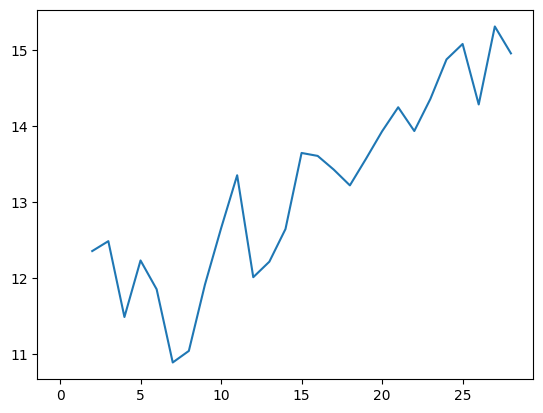

In [90]:
plt.plot(doppler_all[:,0])

有多少个NaN值 1291
拟合得到的OI多普勒速度为 10.326824673465714 km/s
拟合得到的CI多普勒速度为 16.604613355333107 km/s


Text(0.03, 0.95, 'OI Doppler = 10.32 km/s\nCI Doppler = 16.60 km/s')

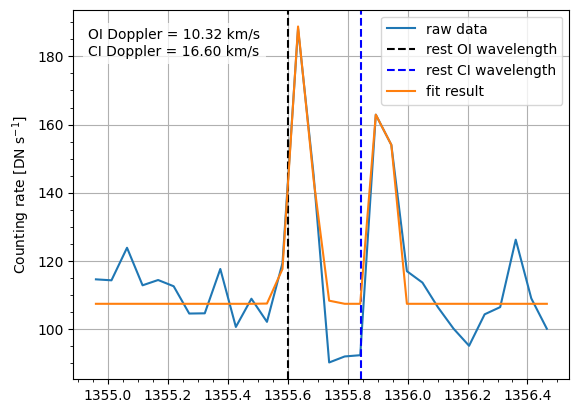

In [92]:
i=1
selected = spectrum_clean_all[i*3][100:300, :]+spectrum_clean_all[i*3+1][100:300, :]+spectrum_clean_all[i*3+2][100:300, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -600))
selected[selected == -600] = np.nan
wave_y1 = np.nansum(selected, axis=0)
wave_y1=wave_y1/(exptime*3)
start_point,end_point=155,185
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Counting rate [DN s$^{-1}$]")
#plt.title('Integrate along the slit T 21:04:35')
plt.legend()
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point],
                           center1_guess=1355.62,center2_guess=1355.92)
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
plt.legend()
plt.minorticks_on()
plt.grid()
plt.text(
            0.03, 0.95,
            f"OI Doppler = 10.32 km/s\nCI Doppler = 16.60 km/s",
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )

In [93]:
doppler_all[1,:]=[10.3268,16.6046]

Text(0.5, 1.0, 'Doppler velocity of OI line in the integrated region over time')

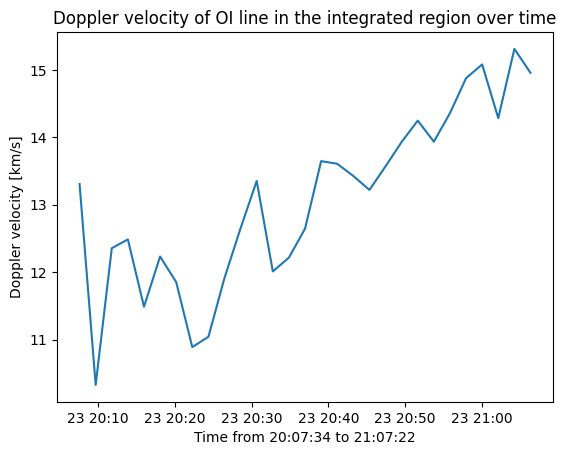

In [94]:
plt.plot(time_axis,doppler_all[:,0])
plt.ylabel('Doppler velocity [km/s]')
plt.xlabel('Time from 20:07:34 to 21:07:22')
plt.title('Doppler velocity of OI line in the integrated region over time')

In [ ]:
#----------------------------------------------------------------------------
#改成选取包含爆发区域的，看爆发前后是否有明显速度变化
#--------------------------------------------------------------------------

In [62]:
#一：从Frame621(20:07:34)开始，时间上三张图在一块增加信噪比（cadence 21s)
from array_despike import array_despike
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
spectrum_clean_all=[]

for i in range(310,484):
    rsm=fits.open(file_list[i])
    spectrum=rsm[2].data[4,:,:]
    exptime=rsm[0].header['EXPTIME']

    #IRIS会将一些NaN设置为-200
    valid_mask = (
        np.isfinite(spectrum)
        & (spectrum != -200)
    )

    spectrum_clean, info = array_despike(
        spectrum,
        sigma=8.0,
        threshold=6.0,
        itmax=20,
        no_low=False,
        valid_mask=valid_mask,
        return_info=True,
        verbose=True,
    )
    spectrum_clean_all.append(spectrum_clean)

bright pass 0: replaced 703 pixels
bright pass 1: replaced 91 pixels
bright pass 2: replaced 27 pixels
bright pass 3: replaced 5 pixels
bright pass 4: replaced 2 pixels
bright pass 5: replaced 4 pixels
bright pass 6: replaced 2 pixels
bright pass 7: replaced 3 pixels
bright pass 8: replaced 2 pixels
bright pass 9: replaced 1 pixels
bright pass 10: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 621 pixels
bright pass 1: replaced 87 pixels
bright pass 2: replaced 23 pixels
bright pass 3: replaced 12 pixels
bright pass 4: replaced 10 pixels
bright pass 5: replaced 7 pixels
bright pass 6: replaced 2 pixels
bright pass 7: replaced 0 pixels
dark pass 0: replaced 1 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 656 pixels
bright pass 1: replaced 91 pixels
bright pass 2: replaced 30 pixels
bright pass 3: replaced 20 pixels
bright pass 4: replaced 5 pixels
bright pass 5: replaced 1 pixels
bright pass 6: replaced 0 pixels
dark pass 0: replaced 5 pixels
da

In [79]:
wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)
doppler_all=np.zeros((58,2))
#接下来进行空间上积分和时间上的三合一
time_axis = pd.date_range(
    start="20:07:34",
    periods=58,
    freq="126s"
)
for i in range(58):
    selected = spectrum_clean_all[i*3][430:630,:]+spectrum_clean_all[i*3+1][430:630,:]+spectrum_clean_all[i*3+2][430:630, :]
    selected = selected.astype(float)
    print('有多少个NaN值',np.count_nonzero(selected == -600))
    selected[selected == -600] = np.nan
    wave_y1 = np.nansum(selected, axis=0)
    wave_y1=wave_y1/(exptime*3)
    start_point,end_point=155,185
    try:
        plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
        plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
        plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
        plt.ylabel(r"Counting rate [DN s$^{-1}$]")
        plt.title(str(i))
        plt.legend()
        from gaussian_fit import fit_double_gaussian
        result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
        centers = np.array([result['center1'], result['center2']])
        centers = np.sort(centers)

        center_OI = centers[0]
        center_CI = centers[1]

        doppler_all[i, 0] = (center_OI - 1355.599) / 1355.599 * 2.997e5
        doppler_all[i, 1] = (center_CI - 1355.844) / 1355.844 * 2.997e5
        plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
        plt.title(time_axis[i])
        plt.minorticks_on()
        plt.grid()
        plt.text(
            0.03, 0.95,
            f"OI Doppler = {doppler_all[i,0]:.2f} km/s\nCI Doppler = {doppler_all[i,1]:.2f} km/s",
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )
        plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\OI_fig_active\{i}.png'.format(i=i))

    except:
        doppler_all[i,0]=np.nan
        doppler_all[i,1]=np.nan
        print(f"Failed to fit double Gaussian for index {i}")
    plt.close()

有多少个NaN值 1308
有多少个NaN值 1309
有多少个NaN值 1308
有多少个NaN值 1309
有多少个NaN值 1305
有多少个NaN值 1306
有多少个NaN值 1295
有多少个NaN值 1299
有多少个NaN值 1296
有多少个NaN值 1289
有多少个NaN值 1294
有多少个NaN值 1290
有多少个NaN值 1291
有多少个NaN值 1286
有多少个NaN值 1282
有多少个NaN值 1282
有多少个NaN值 1278
有多少个NaN值 1280
有多少个NaN值 1280
Failed to fit double Gaussian for index 18
有多少个NaN值 1273
有多少个NaN值 1278
有多少个NaN值 1275
有多少个NaN值 1279
有多少个NaN值 1275
有多少个NaN值 1272
有多少个NaN值 1276
有多少个NaN值 1279
有多少个NaN值 1280
有多少个NaN值 1278
有多少个NaN值 1283
有多少个NaN值 1280
有多少个NaN值 1286
有多少个NaN值 1280
有多少个NaN值 1287
有多少个NaN值 1289
有多少个NaN值 1288
有多少个NaN值 1297
Failed to fit double Gaussian for index 36
有多少个NaN值 1298
有多少个NaN值 1301
有多少个NaN值 1300
有多少个NaN值 1305
有多少个NaN值 1304
有多少个NaN值 1308
有多少个NaN值 1307
有多少个NaN值 1309
有多少个NaN值 1310
有多少个NaN值 1309
有多少个NaN值 1309
有多少个NaN值 1309
有多少个NaN值 1309
有多少个NaN值 1309
有多少个NaN值 1307
Failed to fit double Gaussian for index 51
有多少个NaN值 1305
有多少个NaN值 1305
有多少个NaN值 1303
有多少个NaN值 1301
有多少个NaN值 1296
有多少个NaN值 1294


Text(0.5, 1.0, 'Active region OI line Doppler velocity over time')

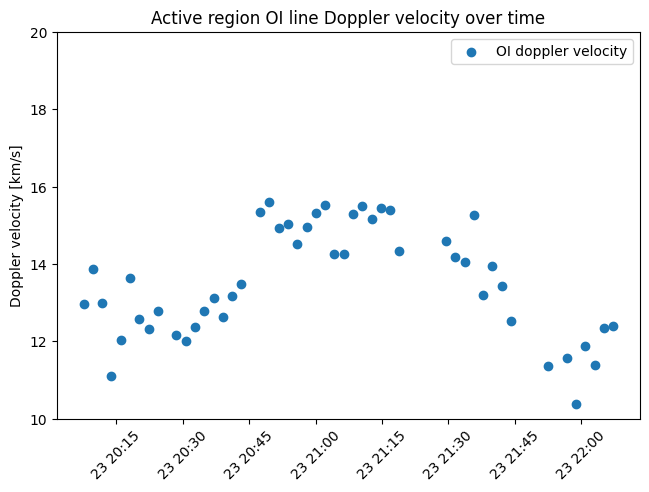

In [86]:
doppler_all[doppler_all<0]=np.nan
import pandas as pd
import matplotlib.pyplot as plt

time_axis = pd.date_range(
    start="20:07:34",
    periods=58,
    freq="126s"
)

plt.scatter(time_axis, doppler_all[:, 0], label="OI doppler velocity")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(10,20)
plt.ylabel('Doppler velocity [km/s]')
plt.title('Active region OI line Doppler velocity over time')